# GT solvent nearest-polymer distances

This notebook is intentionally self-contained. It reads the processed `.npz` structures for the PDB IDs listed in `imputation/easy.txt`, extracts present ground-truth water oxygens and present polymer atoms, computes the nearest polymer atom distance for every GT water, aggregates those distances across the full easy set, and reports:

- overall mean / median / min / max nearest-polymer distance
- per-structure nearest-polymer distance summaries
- any skipped structures

All helper functions are defined inside this notebook.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

EASY_LIST_PATH = Path("/data/rbg/users/gloriama/dev/water_conservation/imputation/easy.txt")
STRUCTURES_DIR = Path("/data/rbg/shared/datasets/processed_rcsb/rcsb_solvents/structures")

MOL_TYPE_POLYMER = 0
MOL_TYPE_WATER = 4

In [3]:
def read_pdb_ids(path: Path) -> list[str]:
    return [line.strip().upper() for line in path.read_text().splitlines() if line.strip()]


def load_npz(pdb_id: str):
    npz_path = STRUCTURES_DIR / f"{pdb_id.lower()}.npz"
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing structure file: {npz_path}")
    return np.load(npz_path, allow_pickle=True)


def get_present_polymer_atom_coords(npz) -> np.ndarray:
    chains = npz["chains"]
    atoms = npz["atoms"]
    polymer_coords = []

    for chain in chains:
        if int(chain["mol_type"]) != MOL_TYPE_POLYMER:
            continue
        atom_start = int(chain["atom_idx"])
        atom_end = atom_start + int(chain["atom_num"])
        chain_atoms = atoms[atom_start:atom_end]
        present_mask = chain_atoms["is_present"]
        if present_mask.any():
            polymer_coords.append(chain_atoms["coords"][present_mask])

    if not polymer_coords:
        return np.empty((0, 3), dtype=np.float32)

    return np.concatenate(polymer_coords, axis=0).astype(np.float32, copy=False)


def get_present_water_oxygen_coords(npz) -> np.ndarray:
    chains = npz["chains"]
    atoms = npz["atoms"]
    water_coords = []

    for chain in chains:
        if int(chain["mol_type"]) != MOL_TYPE_WATER:
            continue
        atom_start = int(chain["atom_idx"])
        atom_end = atom_start + int(chain["atom_num"])
        chain_atoms = atoms[atom_start:atom_end]
        oxygen_mask = (chain_atoms["name"] == "O") & chain_atoms["is_present"]
        if oxygen_mask.any():
            water_coords.append(chain_atoms["coords"][oxygen_mask])

    if not water_coords:
        return np.empty((0, 3), dtype=np.float32)

    return np.concatenate(water_coords, axis=0).astype(np.float32, copy=False)


def compute_min_water_to_polymer_distances(npz) -> np.ndarray:
    polymer_coords = get_present_polymer_atom_coords(npz)
    water_coords = get_present_water_oxygen_coords(npz)

    if len(polymer_coords) == 0 or len(water_coords) == 0:
        return np.empty((0,), dtype=np.float32)

    polymer_tree = cKDTree(polymer_coords)
    distances, _ = polymer_tree.query(water_coords, k=1)
    return np.asarray(distances, dtype=np.float32)


def summarize_distances(distances: np.ndarray) -> dict[str, float]:
    if len(distances) == 0:
        return {
            "count": 0,
            "mean_min_dist": np.nan,
            "median_min_dist": np.nan,
            "min_min_dist": np.nan,
            "max_min_dist": np.nan,
        }

    return {
        "count": int(len(distances)),
        "mean_min_dist": float(distances.mean()),
        "median_min_dist": float(np.median(distances)),
        "min_min_dist": float(distances.min()),
        "max_min_dist": float(distances.max()),
    }


def analyze_structure(pdb_id: str) -> tuple[dict, np.ndarray]:
    with load_npz(pdb_id) as npz:
        distances = compute_min_water_to_polymer_distances(npz)

    summary = summarize_distances(distances)
    summary["pdb_id"] = pdb_id
    summary["num_waters"] = summary.pop("count")
    return summary, distances


def analyze_pdb_ids(pdb_ids: list[str]) -> tuple[pd.DataFrame, np.ndarray, pd.DataFrame]:
    per_structure_records = []
    all_distance_arrays = []
    skipped_records = []

    for pdb_id in pdb_ids:
        try:
            summary, distances = analyze_structure(pdb_id)
        except Exception as exc:
            skipped_records.append({"pdb_id": pdb_id, "reason": repr(exc)})
            continue

        if len(distances) == 0:
            skipped_records.append(
                {
                    "pdb_id": pdb_id,
                    "reason": "No present GT water oxygens or no present polymer atoms.",
                }
            )
            continue

        per_structure_records.append(summary)
        all_distance_arrays.append(distances)

    per_structure_df = pd.DataFrame(per_structure_records)
    skipped_df = pd.DataFrame(skipped_records)

    if all_distance_arrays:
        all_min_distances = np.concatenate(all_distance_arrays)
    else:
        all_min_distances = np.empty((0,), dtype=np.float32)

    return per_structure_df, all_min_distances, skipped_df

## Run the easy-set analysis

This cell computes the nearest-polymer distance for every GT water oxygen across every PDB ID in `easy.txt`, then builds an overall summary table in Angstrom.

Overall nearest-polymer distances across 8155 GT waters: mean=3.006 Angstrom, median=2.856 Angstrom, min=1.615 Angstrom, max=8.369 Angstrom


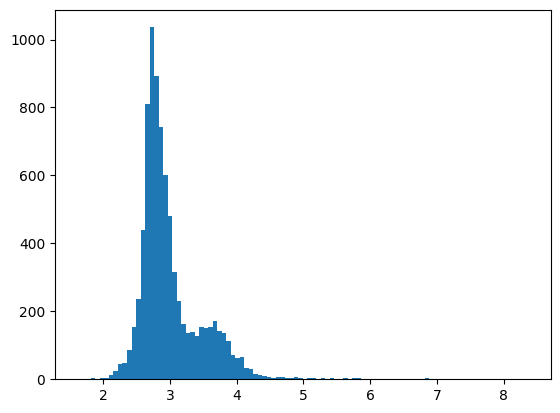

In [6]:
pdb_ids = read_pdb_ids(EASY_LIST_PATH)
per_structure_df, all_min_distances, skipped_df = analyze_pdb_ids(pdb_ids)

distance_summary = summarize_distances(all_min_distances)
overall_summary_df = pd.DataFrame(
    [
        {
            "num_structures_requested": len(pdb_ids),
            "num_structures_with_distances": int(len(per_structure_df)),
            "num_structures_skipped": int(len(skipped_df)),
            "num_water_oxygens_aggregated": int(len(all_min_distances)),
            "mean_min_dist": distance_summary["mean_min_dist"],
            "median_min_dist": distance_summary["median_min_dist"],
            "min_min_dist": distance_summary["min_min_dist"],
            "max_min_dist": distance_summary["max_min_dist"],
        }
    ]
)

print(
    f"Overall nearest-polymer distances across {len(all_min_distances)} GT waters: "
    f"mean={distance_summary['mean_min_dist']:.3f} Angstrom, "
    f"median={distance_summary['median_min_dist']:.3f} Angstrom, "
    f"min={distance_summary['min_min_dist']:.3f} Angstrom, "
    f"max={distance_summary['max_min_dist']:.3f} Angstrom"
)

overall_summary_df.round(3)

plt.hist(all_min_distances, bins=100)
plt.show()


## Per-structure summaries

Each row summarizes the GT water oxygen nearest-polymer distances for one structure.

In [7]:
per_structure_df.sort_values("pdb_id").reset_index(drop=True).round(3)

,mean_min_dist,median_min_dist,min_min_dist,max_min_dist,pdb_id,num_waters
0,2.961,2.841,2.404,4.235,7QRL,98
1,2.945,2.818,1.946,4.105,7VS2,122
2,2.996,2.839,2.319,5.540,7YD4,90
3,3.065,2.841,1.848,7.161,7YH3,339
4,3.023,2.858,2.107,6.121,7YLR,400
5,2.914,2.818,2.484,4.262,7Z3I,126
6,3.016,2.884,2.349,4.257,8A9N,236
7,3.014,2.823,1.857,6.867,8AXJ,157
8,3.109,2.984,2.463,5.150,8B4U,194
9,3.025,2.915,2.055,4.985,8B5W,408


## Skipped structures

This should be empty for a complete run. If not, inspect the reported reason before trusting the aggregate stats.

In [8]:
if skipped_df.empty:
    print("No structures were skipped.")
else:
    skipped_df

No structures were skipped.
